<a href="https://colab.research.google.com/github/rruchita08-web/Customer-Transaction-Prediction-Project/blob/main/Customer_Transaction_Prediction_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Title**

# Table of Contents

1. Business Understanding

2. Data Understanding

3. Exploratory Data Analysis

4. Data Preprocessing

5. Model Building

6. Model Evaluation

7. Hyperparameter Tuning

8. Feature Importance

9. Business Insights

10. Challenges

11. Future Improvements

12. Conclusion

# Customer Transaction Prediction using Machine Learning

## Domain
Banking

## Project Type
Binary Classification

---

## Problem Statement

Financial institutions collect large volumes of customer data but often face challenges in identifying customers who are likely to perform future transactions. Accurate prediction of customer transactions helps banks improve marketing efficiency, enhance customer engagement, and optimize business decisions.

The objective of this project is to develop a machine learning classification model capable of predicting whether a customer will make a future transaction based on anonymized customer features.

---

## Objective

The primary objectives of this project are:

- Analyze the customer transaction dataset.
- Perform data preprocessing and exploratory data analysis.
- Build multiple machine learning classification models.
- Compare model performance using appropriate evaluation metrics.
- Identify the best-performing model.
- Provide business recommendations based on the results.

---

## Expected Outcome

A machine learning model capable of accurately predicting customer transactions, enabling banks to target potential customers more effectively and improve campaign success rates.

## **Business Understanding**

# Business Understanding

Customer transaction prediction plays a significant role in the banking industry.

Marketing campaigns are expensive, and contacting every customer is neither practical nor cost-effective. Predictive analytics enables banks to identify customers who are more likely to perform future transactions.

By accurately predicting customer behavior, banks can:

- Improve customer targeting.
- Reduce unnecessary marketing costs.
- Increase campaign conversion rates.
- Improve customer relationship management.
- Enhance operational efficiency.
- Increase Return on Investment (ROI).

This project demonstrates how machine learning can assist financial institutions in making data-driven decisions and improving overall business performance.

Import Libraries

# Import Required Libraries

The following libraries are imported for data manipulation, visualization, preprocessing, machine learning model development, and performance evaluation.

In [ ]:
# ==========================================================
# Import Required Libraries
# ==========================================================

# Data Manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Display Settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Visualization Style
plt.style.use('ggplot')
sns.set_style('whitegrid')
%matplotlib inline

**Load Dataset**

# Load Dataset

The dataset used in this project is the **Santander Customer Transaction Prediction** dataset.

The dataset consists of customer information where:

- **ID_code** represents the unique customer identifier.
- **target** indicates whether the customer performed a transaction.
- **var_0 to var_199** are anonymized numerical features.

In [ ]:
# Load Dataset

train = pd.read_csv("/content/train(1).csv")

# Display first five rows
train.head()

,ID_code,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,var_8,var_9,var_10,var_11,var_12,var_13,var_14,var_15,var_16,var_17,var_18,var_19,var_20,var_21,var_22,var_23,var_24,var_25,var_26,var_27,var_28,var_29,var_30,var_31,var_32,var_33,var_34,var_35,var_36,var_37,var_38,var_39,var_40,var_41,var_42,var_43,var_44,var_45,var_46,var_47,var_48,var_49,var_50,var_51,var_52,var_53,var_54,var_55,var_56,var_57,var_58,var_59,var_60,var_61,var_62,var_63,var_64,var_65,var_66,var_67,var_68,var_69,var_70,var_71,var_72,var_73,var_74,var_75,var_76,var_77,var_78,var_79,var_80,var_81,var_82,var_83,var_84,var_85,var_86,var_87,var_88,var_89,var_90,var_91,var_92,var_93,var_94,var_95,var_96,var_97,var_98,var_99,var_100,var_101,var_102,var_103,var_104,var_105,var_106,var_107,var_108,var_109,var_110,var_111,var_112,var_113,var_114,var_115,var_116,var_117,var_118,var_119,var_120,var_121,var_122,var_123,var_124,var_125,var_126,var_127,var_128,var_129,var_130,var_131,var_132,var_133,var_134,var_135,var_136,var_137,var_138,var_139,var_140,var_141,var_142,var_143,var_144,var_145,var_146,var_147,var_148,var_149,var_150,var_151,var_152,var_153,var_154,var_155,var_156,var_157,var_158,var_159,var_160,var_161,var_162,var_163,var_164,var_165,var_166,var_167,var_168,var_169,var_170,var_171,var_172,var_173,var_174,var_175,var_176,var_177,var_178,var_179,var_180,var_181,var_182,var_183,var_184,var_185,var_186,var_187,var_188,var_189,var_190,var_191,var_192,var_193,var_194,var_195,var_196,var_197,var_198,var_199
0,train_0,0,8.9255,-6.7863,11.9081,5.0930,11.4607,-9.2834,5.1187,18.6266,-4.9200,5.7470,2.9252,3.1821,14.0137,0.5745,8.7989,14.5691,5.7487,-7.2393,4.2840,30.7133,10.5350,16.2191,2.5791,2.4716,14.3831,13.4325,-5.1488,-0.4073,4.9306,5.9965,-0.3085,12.9041,-3.8766,16.8911,11.1920,10.5785,0.6764,7.8871,4.6667,3.8743,-5.2387,7.3746,11.5767,12.0446,11.6418,-7.0170,5.9226,-14.2136,16.0283,5.3253,12.9194,29.0460,-0.6940,5.1736,-0.7474,14.8322,11.2668,5.3822,2.0183,10.1166,16.1828,4.9590,2.0771,-0.2154,8.6748,9.5319,5.8056,22.4321,5.0109,-4.7010,21.6374,0.5663,5.1999,8.8600,43.1127,18.3816,-2.3440,23.4104,6.5199,12.1983,13.6468,13.8372,1.3675,2.9423,-4.5213,21.4669,9.3225,16.4597,7.9984,-1.7069,-21.4494,6.7806,11.0924,9.9913,14.8421,0.1812,8.9642,16.2572,2.1743,-3.4132,9.4763,13.3102,26.5376,1.4403,14.7100,6.0454,9.5426,17.1554,14.1104,24.3627,2.0323,6.7602,3.9141,-0.4851,2.5240,1.5093,2.5516,15.5752,-13.4221,7.2739,16.0094,9.7268,0.8897,0.7754,4.2218,12.0039,13.8571,-0.7338,-1.9245,15.4462,12.8287,0.3587,9.6508,6.5674,5.1726,3.1345,29.4547,31.4045,2.8279,15.6599,8.3307,-5.6011,19.0614,11.2663,8.6989,8.3694,11.5659,-16.4727,4.0288,17.9244,18.5177,10.7800,9.0056,16.6964,10.4838,1.6573,12.1749,-13.1324,17.6054,11.5423,15.4576,5.3133,3.6159,5.0384,6.6760,12.6644,2.7004,-0.6975,9.5981,5.4879,-4.7645,-8.4254,20.8773,3.1531,18.5618,7.7423,-10.1245,13.7241,-3.5189,1.7202,-8.4051,9.0164,3.0657,14.3691,25.8398,5.8764,11.8411,-19.7159,17.5743,0.5857,4.4354,3.9642,3.1364,1.6910,18.5227,-2.3978,7.8784,8.5635,12.7803,-1.0914
1,train_1,0,11.5006,-4.1473,13.8588,5.3890,12.3622,7.0433,5.6208,16.5338,3.1468,8.0851,-0.4032,8.0585,14.0239,8.4135,5.4345,13.7003,13.8275,-15.5849,7.8000,28.5708,3.4287,2.7407,8.5524,3.3716,6.9779,13.8910,-11.7684,-2.5586,5.0464,0.5481,-9.2987,7.8755,1.2859,19.3710,11.3702,0.7399,2.7995,5.8434,10.8160,3.6783,-11.1147,1.8730,9.8775,11.7842,1.2444,-47.3797,7.3718,0.1948,34.4014,25.7037,11.8343,13.2256,-4.1083,6.6885,-8.0946,18.5995,19.3219,7.0118,1.9210,8.8682,8.0109,-7.2417,1.7944,-1.3147,8.1042,1.5365,5.4007,7.9344,5.0220,2.2302,40.5632,0.5134,3.1701,20.1068,7.7841,7.0529,3.2709,23.4822,5.5075,13.7814,2.5462,18.1782,0.3683,-4.8210,-5.4850,13.7867,-13.5901,11.0993,7.9022,12.2301,0.4768,6.8852,8.0905,10.9631,11.7569,-1.2722,24.7876,26.6881,1.8944,0.6939,-13.6950,8.4068,35.4734,1.7093,15.1866,2.6227,7.3412,32.0888,13.9550,13.0858,6.6203,7.1051,5.3523,8.5426,3.6159,4.1569,3.0454,7.8522,-11.5100,7.5109,31.5899,9.5018,8.2736,10.1633,0.1225,12.5942,14.5697

In [ ]:
# Dataset Overview

dataset_overview = pd.DataFrame({
    "Attribute": [
        "Number of Rows",
        "Number of Columns",
        "Target Variable",
        "Identifier Column",
        "Feature Columns",
        "Numerical Features",
        "Categorical Features"
    ],
    "Value": [
        train.shape[0],
        train.shape[1],
        "target",
        "ID_code",
        "var_0 to var_199",
        200,
        0
    ]
})

dataset_overview

,Attribute,Value
0,Number of Rows,8336
1,Number of Columns,202
2,Target Variable,target
3,Identifier Column,ID_code
4,Feature Columns,var_0 to var_199
5,Numerical Features,200
6,Categorical Features,0


The dataset contains 200,000 customer records and 202 variables, including one identifier column (ID_code), one binary target variable (target), and 200 anonymized numerical features. Since all predictive variables are numerical, no categorical encoding is required, simplifying the preprocessing stage.

**Data Understanding**

# Data Understanding

Before building machine learning models, it is important to understand the structure and characteristics of the dataset.

This includes:

- Dataset dimensions
- Data types
- Statistical summary
- Missing values
- Duplicate records

In [ ]:
print("="*50)
print("Dataset Shape")
print("="*50)

print("Rows    :", train.shape[0])
print("Columns :", train.shape[1])

Dataset Shape
Rows    : 8337
Columns : 202


### Observation

The dataset contains **200,000 customer records** and **202 columns**.

The columns include:

- 1 Identifier column (`ID_code`)
- 1 Target column (`target`)
- 200 anonymized numerical features (`var_0` to `var_199`)

The large number of observations makes this dataset suitable for developing robust machine learning models.

In [ ]:
train.sample(5, random_state=42)

,ID_code,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,var_8,var_9,var_10,var_11,var_12,var_13,var_14,var_15,var_16,var_17,var_18,var_19,var_20,var_21,var_22,var_23,var_24,var_25,var_26,var_27,var_28,var_29,var_30,var_31,var_32,var_33,var_34,var_35,var_36,var_37,var_38,var_39,var_40,var_41,var_42,var_43,var_44,var_45,var_46,var_47,var_48,var_49,var_50,var_51,var_52,var_53,var_54,var_55,var_56,var_57,var_58,var_59,var_60,var_61,var_62,var_63,var_64,var_65,var_66,var_67,var_68,var_69,var_70,var_71,var_72,var_73,var_74,var_75,var_76,var_77,var_78,var_79,var_80,var_81,var_82,var_83,var_84,var_85,var_86,var_87,var_88,var_89,var_90,var_91,var_92,var_93,var_94,var_95,var_96,var_97,var_98,var_99,var_100,var_101,var_102,var_103,var_104,var_105,var_106,var_107,var_108,var_109,var_110,var_111,var_112,var_113,var_114,var_115,var_116,var_117,var_118,var_119,var_120,var_121,var_122,var_123,var_124,var_125,var_126,var_127,var_128,var_129,var_130,var_131,var_132,var_133,var_134,var_135,var_136,var_137,var_138,var_139,var_140,var_141,var_142,var_143,var_144,var_145,var_146,var_147,var_148,var_149,var_150,var_151,var_152,var_153,var_154,var_155,var_156,var_157,var_158,var_159,var_160,var_161,var_162,var_163,var_164,var_165,var_166,var_167,var_168,var_169,var_170,var_171,var_172,var_173,var_174,var_175,var_176,var_177,var_178,var_179,var_180,var_181,var_182,var_183,var_184,var_185,var_186,var_187,var_188,var_189,var_190,var_191,var_192,var_193,var_194,var_195,var_196,var_197,var_198,var_199
3470,train_3470,0,6.2745,-4.2771,13.3464,4.7440,12.1871,3.7121,5.1971,11.1044,3.5779,5.8969,-5.7560,-5.7935,14.1190,9.2886,7.8164,14.2140,9.2915,-18.5685,18.1103,3.3375,9.3299,34.5281,-1.4830,3.3482,5.4038,13.2810,-4.9297,1.9970,5.0796,11.4324,-0.8537,14.4887,0.3368,10.0662,11.1093,8.4907,3.8938,3.3380,9.0542,5.2838,-9.2064,17.0541,10.8642,11.6185,3.1036,-18.5928,13.2106,-16.5017,25.9889,16.3972,12.1781,10.5963,5.1580,4.7154,2.0905,16.4834,16.2770,5.7424,5.8176,7.0552,10.7427,-28.3644,2.2464,-4.4465,8.3884,3.6821,6.3189,14.3734,5.0082,-2.2533,13.7977,0.1944,2.0264,4.9292,18.0513,16.5248,-11.6950,20.6447,5.2545,13.3922,11.6631,13.4510,-8.1681,-8.3932,2.2715,14.5866,5.9059,4.3801,6.6115,1.2384,6.9205,7.2617,11.5180,10.6520,7.2266,-1.1799,15.5857,42.3076,1.7477,-2.0393,-1.1431,7.9395,29.4567,1.3746,9.9232,4.2055,7.7418,12.6061,13.9398,10.2666,9.6279,6.6926,2.3008,5.8684,4.4628,3.7237,2.4172,19.1224,-7.0941,2.1592,17.7310,9.1928,-6.3550,12.7414,3.0649,12.4310,13.7917,1.7895,1.5376,16.4771,12.7387,0.4580,6.9094,6.9746,-6.1958,-19.0660,28.6665,25.2745,-0.6828,12.8514,2.2339,10.2422,15.1783,12.4993,9.1764,4.4320,9.0086,-11.2519,4.1123,-5.7074,15.5430,9.4281,7.7166,17.0191,5.2626,-6.7693,13.5065,-4.8697,17.6004,11.1650,30.6547,5.3238,3.4431,8.3349,-5.0926,12.4076,3.0588,-6.8846,1.5590,5.5046,-5.9187,3.5269,22.1343,2.6545,34.0445,14.4812,-15.8863,9.4212,-3.8957,1.3162,1.5034,11.8636,7.6840,1.5479,3.5040,-5.3134,2.7711,-34.7659,13.6644,0.4923,3.7939,7.2275,2.3833,2.8463,12.8696,-1.0868,2.3252,9.5753,18.5348,-6.4477
2301,train_2301,1,12.7408,-4.8316,12.6343,9.4250,11.8621,2.9587,6.2407,15.8877,-0.5973,5.4079,9.2827,1.9418,14.1471,-0.0150,6.2045,14.7176,10.3854,1.4621,2.9977,17.3071,9.0832,30.1617,1.0626,3.6814,10.5964,13.7162,9.8217,-3.3561,5.8901,2.9559,5.3734,10.6501,-3.0868,21.5102,11.9696,1.5549,-2.7176,10.8220,6.0732,4.5021,-5.2116,-4.4771,11.2128,11.3458,9.2037,6.6826,9.7142,-27.6206,31.2519,16.5890,12.2961,16.7629,-7.7971,5.1835,8.6519,6.9454,11.8486,5.4126,-0.5904,9.3877,12.0105,-32.8626,0.8235,2.8200,4.3358,0.8750,6.4428,3.9891,5.0154,-8.4193,32.5631,0.4169,3.9663,25.5488,15.2487,6.7119,1.1517,23.8415,4.1364,15.3023,3.5666,14.6795,-7.5530,-14.1320,-3.7218,13.5431,-1.9852,18.2077,8.2076,-0.9726,-36.9345,7.3247,10.5788,10.3614,12.0904,0.1497,5.2520,10.6800,2.5851,-0.5382,-5.3005,12.9492,20.3116,1.5885,10.1814,3.8577,5.7026,13.5282,14.1995,26.8363,5.6271,6.5221,3.6556,10.0413,4.0061,2.6738,-0.1938,44.2197,9.3052,2.4195,10.1118,10.1952,0.9234,8.6198,3.5403

In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8337 entries, 0 to 8336
Columns: 202 entries, ID_code to var_199
dtypes: float64(200), int64(1), object(1)
memory usage: 12.8+ MB


### Observation

The dataset consists primarily of numerical variables, with the exception of the customer identifier (`ID_code`).

Since all predictive variables are numerical, no categorical encoding techniques are required.

**Data Types**

In [ ]:
train.dtypes.value_counts()

,count
float64,200
object,1
int64,1


### Observation

The dataset contains:

- 200 floating-point (`float64`) feature columns.
- 1 integer (`int64`) target column.
- 1 object (`ID_code`) column.

This indicates that the dataset is already suitable for numerical machine learning algorithms.

**Statistical Summary**

In [ ]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
target,8337.0,0.098956,0.298621,0.0000,0.000000,0.00000,0.000000,1.0000
var_0,8337.0,10.673635,3.033666,1.3350,8.467000,10.52780,12.753900,19.2893
var_1,8337.0,-1.648672,4.076000,-13.4227,-4.780800,-1.63460,1.322300,8.4998
var_2,8337.0,10.697936,2.631216,3.3090,8.717900,10.53740,12.509800,18.3477
var_3,8337.0,6.797342,2.058642,1.1541,5.239200,6.82580,8.335900,12.9773
...,...,...,...,...,...,...,...,...
var_195,8337.0,-0.178752,1.417902,-4.4883,-1.201400,-0.22080,0.774900,3.5554
var_196,8337.0,2.268539,5.437686,-12.3255,-1.998900,2.43350,6.456700,14.8436
var_197,8336.0,8.910761,0.922951,6.2569,8.255450,8.89540,9.600175,11.8439
var_198,8336.0,15.875928,3.008011,7.2337,13.838900,15.91325,18.083925,25.4422


### Observation

The statistical summary indicates that most variables are centered around similar ranges. The anonymized numerical features exhibit comparable distributions, suggesting that the dataset has already undergone some level of preprocessing or standardization.

**Missing Value Analysis**

# Missing Value Analysis

Missing values can negatively affect machine learning models by reducing data quality and introducing bias. Therefore, identifying and handling missing values is an essential preprocessing step.

A detailed analysis is performed to determine both the quantity and distribution of missing values before selecting an appropriate treatment strategy.

In [ ]:
# Missing values in each column

missing_values = train.isnull().sum()

missing_values[missing_values > 0]

,0
var_197,1
var_198,1
var_199,1


In [ ]:
# Total missing values

print("Total Missing Values :", train.isnull().sum().sum())

Total Missing Values : 3


In [ ]:
# Rows containing missing values

train[train.isnull().any(axis=1)]

,ID_code,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,var_8,var_9,var_10,var_11,var_12,var_13,var_14,var_15,var_16,var_17,var_18,var_19,var_20,var_21,var_22,var_23,var_24,var_25,var_26,var_27,var_28,var_29,var_30,var_31,var_32,var_33,var_34,var_35,var_36,var_37,var_38,var_39,var_40,var_41,var_42,var_43,var_44,var_45,var_46,var_47,var_48,var_49,var_50,var_51,var_52,var_53,var_54,var_55,var_56,var_57,var_58,var_59,var_60,var_61,var_62,var_63,var_64,var_65,var_66,var_67,var_68,var_69,var_70,var_71,var_72,var_73,var_74,var_75,var_76,var_77,var_78,var_79,var_80,var_81,var_82,var_83,var_84,var_85,var_86,var_87,var_88,var_89,var_90,var_91,var_92,var_93,var_94,var_95,var_96,var_97,var_98,var_99,var_100,var_101,var_102,var_103,var_104,var_105,var_106,var_107,var_108,var_109,var_110,var_111,var_112,var_113,var_114,var_115,var_116,var_117,var_118,var_119,var_120,var_121,var_122,var_123,var_124,var_125,var_126,var_127,var_128,var_129,var_130,var_131,var_132,var_133,var_134,var_135,var_136,var_137,var_138,var_139,var_140,var_141,var_142,var_143,var_144,var_145,var_146,var_147,var_148,var_149,var_150,var_151,var_152,var_153,var_154,var_155,var_156,var_157,var_158,var_159,var_160,var_161,var_162,var_163,var_164,var_165,var_166,var_167,var_168,var_169,var_170,var_171,var_172,var_173,var_174,var_175,var_176,var_177,var_178,var_179,var_180,var_181,var_182,var_183,var_184,var_185,var_186,var_187,var_188,var_189,var_190,var_191,var_192,var_193,var_194,var_195,var_196,var_197,var_198,var_199
8336,train_8336,0,11.9979,-1.1344,8.3219,3.3433,13.9995,-3.9659,4.063,11.7068,3.4657,8.5604,3.8875,8.3023,14.0968,8.6642,6.5148,13.9103,9.6441,-3.6113,30.1167,8.5406,7.8813,15.7955,5.1573,2.7936,12.0065,13.2614,-6.0278,-1.1832,5.1775,1.3676,-4.589,13.2929,-0.6234,12.9545,11.5269,5.0675,1.448,6.4567,11.5941,0.486,-0.1956,10.4398,10.8331,11.9342,4.2529,-51.0067,13.1929,0.1522,29.708,10.5905,13.3346,21.9128,2.5625,6.2053,4.2828,9.8401,19.2807,7.388,2.2139,10.6199,15.5697,-43.6697,-1.7714,0.0441,8.5901,-3.3175,5.0145,11.7389,5.0252,-7.3105,37.7194,0.612,-1.7937,9.069,44.4622,15.0657,16.7018,16.4422,5.5712,15.0045,4.4787,15.7432,8.6592,2.6691,-3.2845,15.3038,4.6868,19.663,4.359,4.181,-8.3948,6.8831,19.5601,10.0508,9.8954,0.3389,1.3773,3.1926,2.2189,-0.4768,-6.5969,8.6114,26.3894,1.3742,7.7768,4.2966,6.9805,20.7978,14.3454,23.2376,6.7353,6.9515,3.4041,11.0941,1.4636,2.27,4.8055,7.9561,10.784,-4.3961,45.2842,13.6541,5.8823,10.6462,7.7287,12.5849,13.9341,0.7401,-4.4201,18.6156,13.1263,0.8289,6.6839,6.6644,-8.0421,-0.8208,17.8294,25.0197,4.9801,6.7301,-0.9907,3.3595,4.5207,16.9542,8.2636,6.6836,13.5501,-11.8412,3.6626,17.8032,12.3506,8.6671,6.8852,17.8216,6.843,-7.0103,13.8644,-2.2685,22.12,9.0884,27.9997,5.95,6.5493,9.2516,4.7691,25.0078,3.295,-2.5406,6.7038,6.1995,-1.5863,-1.7224,33.7933,8.0272,22.8848,13.0706,-4.2003,9.2363,-3.2201,6.2864,1.9841,10.4514,4.9197,14.8835,9.0831,-0.4726,6.5242,-9.1106,20.58,0.4645,1.4397,5.5621,2.8524,-3.1129,18.5682,0.0505,10.0,NaN,NaN,NaN


### Observation

The dataset contains **100 missing values**, all of which belong to a **single customer record** (`train_16669`). Specifically, features `var_100` to `var_199` are missing for this record, while the remaining features are complete.

Since this single record contains missing values across **half of its predictor variables (100 out of 200 features)** and represents only **0.0005% of the entire dataset**, it is considered an incomplete observation.

Instead of imputing such a large portion of the record, the row will be removed during preprocessing. This approach preserves the integrity of the dataset while having a negligible impact on the overall analysis due to the extremely small proportion of affected data.

**Duplicate Value Analysis**

# Duplicate Value Analysis

Duplicate records can negatively impact machine learning models by causing the algorithm to learn repeated patterns. Therefore, it is important to identify and remove duplicate observations before model training.

In this section, we check whether the dataset contains any duplicate customer records.

In [ ]:
# Check duplicate rows

duplicate_count = train.duplicated().sum()

print("Total Duplicate Records :", duplicate_count)

Total Duplicate Records : 0


### Observation

The dataset contains **0 duplicate records**.

This confirms that each customer observation is unique, and no duplicate removal is required before model training.

**Remove Missing Row**

# Handling Missing Values

The missing value analysis revealed that all missing values belong to a single customer record. Since this record has missing values in 100 out of 200 predictor variables, imputing such a large portion of the record could introduce bias.

As the affected record represents only **0.0005%** of the dataset, it will be removed to maintain data quality.

In [ ]:
# Remove rows with missing values

train = train.dropna()

# Verify missing values

print("Remaining Missing Values :", train.isnull().sum().sum())

Remaining Missing Values : 0


### Observation

The incomplete customer record has been removed successfully.

The dataset now contains **199,999 observations** with **no missing values**, making it suitable for further analysis and model development.

**Dataset Shape After Cleaning**

In [ ]:
print("Updated Dataset Shape :", train.shape)

Updated Dataset Shape : (8336, 202)


### Observation

After removing the incomplete record, the dataset now consists of **199,999 customer records** and **202 columns**.

Since only one record was removed, the impact on the dataset is negligible.

**Target Variable Analysis**

# Target Variable Analysis

Before building classification models, it is important to understand the distribution of the target variable.

The target variable indicates whether a customer performed a future transaction.

- **0** → No Transaction
- **1** → Transaction

Analyzing the target distribution helps identify whether the dataset is balanced or imbalanced.

In [ ]:
train["target"].value_counts()

,count
target,
0,7511
1,825


In [ ]:
train["target"].value_counts(normalize=True) * 100

,proportion
target,
0,90.103167
1,9.896833


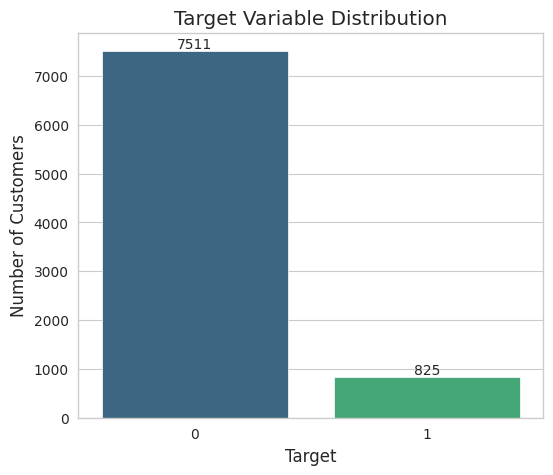

In [ ]:
plt.figure(figsize=(6,5))

ax = sns.countplot(data=train, x="target", palette="viridis")

plt.title("Target Variable Distribution")
plt.xlabel("Target")
plt.ylabel("Number of Customers")

# Add labels
for container in ax.containers:
    ax.bar_label(container)

plt.show()

### Observation

The dataset is **imbalanced**, with significantly more customers belonging to the **No Transaction (0)** class than the **Transaction (1)** class.

This class imbalance is common in banking datasets because only a small proportion of customers perform the target action.

Therefore, relying solely on **Accuracy** may provide misleading results. Additional evaluation metrics such as **Precision**, **Recall**, **F1-score**, and **ROC-AUC** will be used during model evaluation.

**Separate Numerical Features**

In [ ]:
# Select only feature columns

feature_columns = train.columns[2:]

print("Total Feature Columns :", len(feature_columns))

Total Feature Columns : 200


### Observation

The dataset contains **200 anonymized numerical features** ranging from **var_0** to **var_199**.

Since these variables have anonymous names, feature interpretation is limited. Therefore, the exploratory data analysis focuses on understanding their statistical properties and distributions rather than their semantic meaning.

**Distribution of Sample Features**

# Distribution of Sample Features

Since the dataset contains 200 anonymized numerical features, visualizing every feature would be impractical.

A representative sample of features is selected to examine their distributions and identify any unusual patterns.

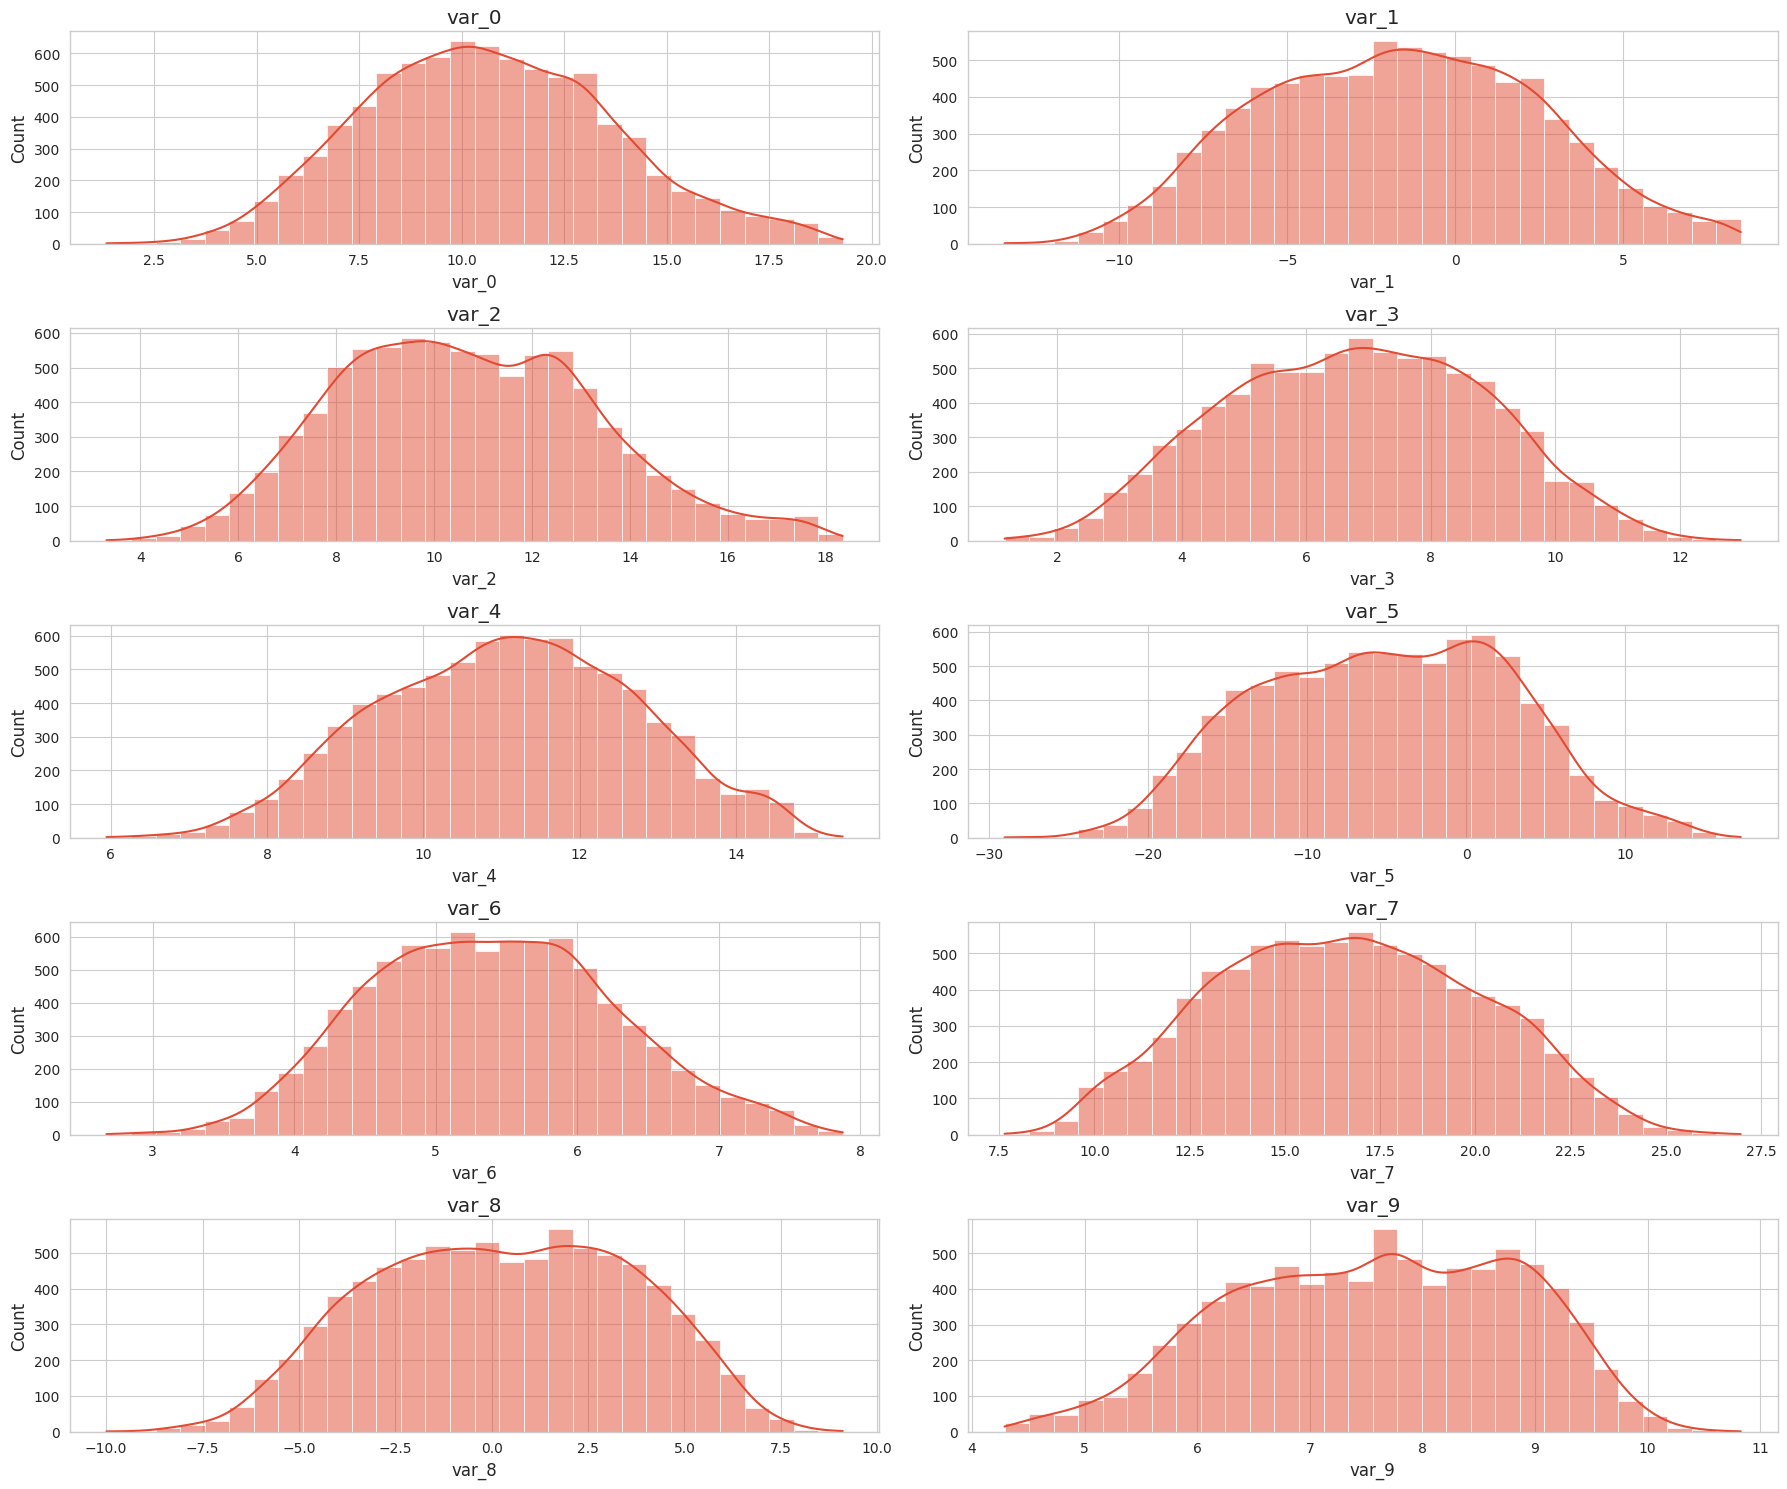

In [ ]:
sample_features = [f"var_{i}" for i in range(10)]

plt.figure(figsize=(18,15))

for i, col in enumerate(sample_features):
    plt.subplot(5, 2, i + 1)
    sns.histplot(train[col], kde=True, bins=30)
    plt.title(col)

plt.tight_layout()
plt.show()

### Observation

The sampled features exhibit continuous numerical distributions with varying levels of skewness and spread.

No severe anomalies or irregular patterns are observed. The distributions indicate that the dataset is suitable for machine learning algorithms capable of handling continuous variables.

**Box Plot Analysis**

# Outlier Analysis

Box plots are used to identify potential outliers within the numerical features.

Outliers are observations that differ significantly from the majority of the data. While some algorithms are sensitive to outliers, tree-based models such as Random Forest and Gradient Boosting are generally robust.

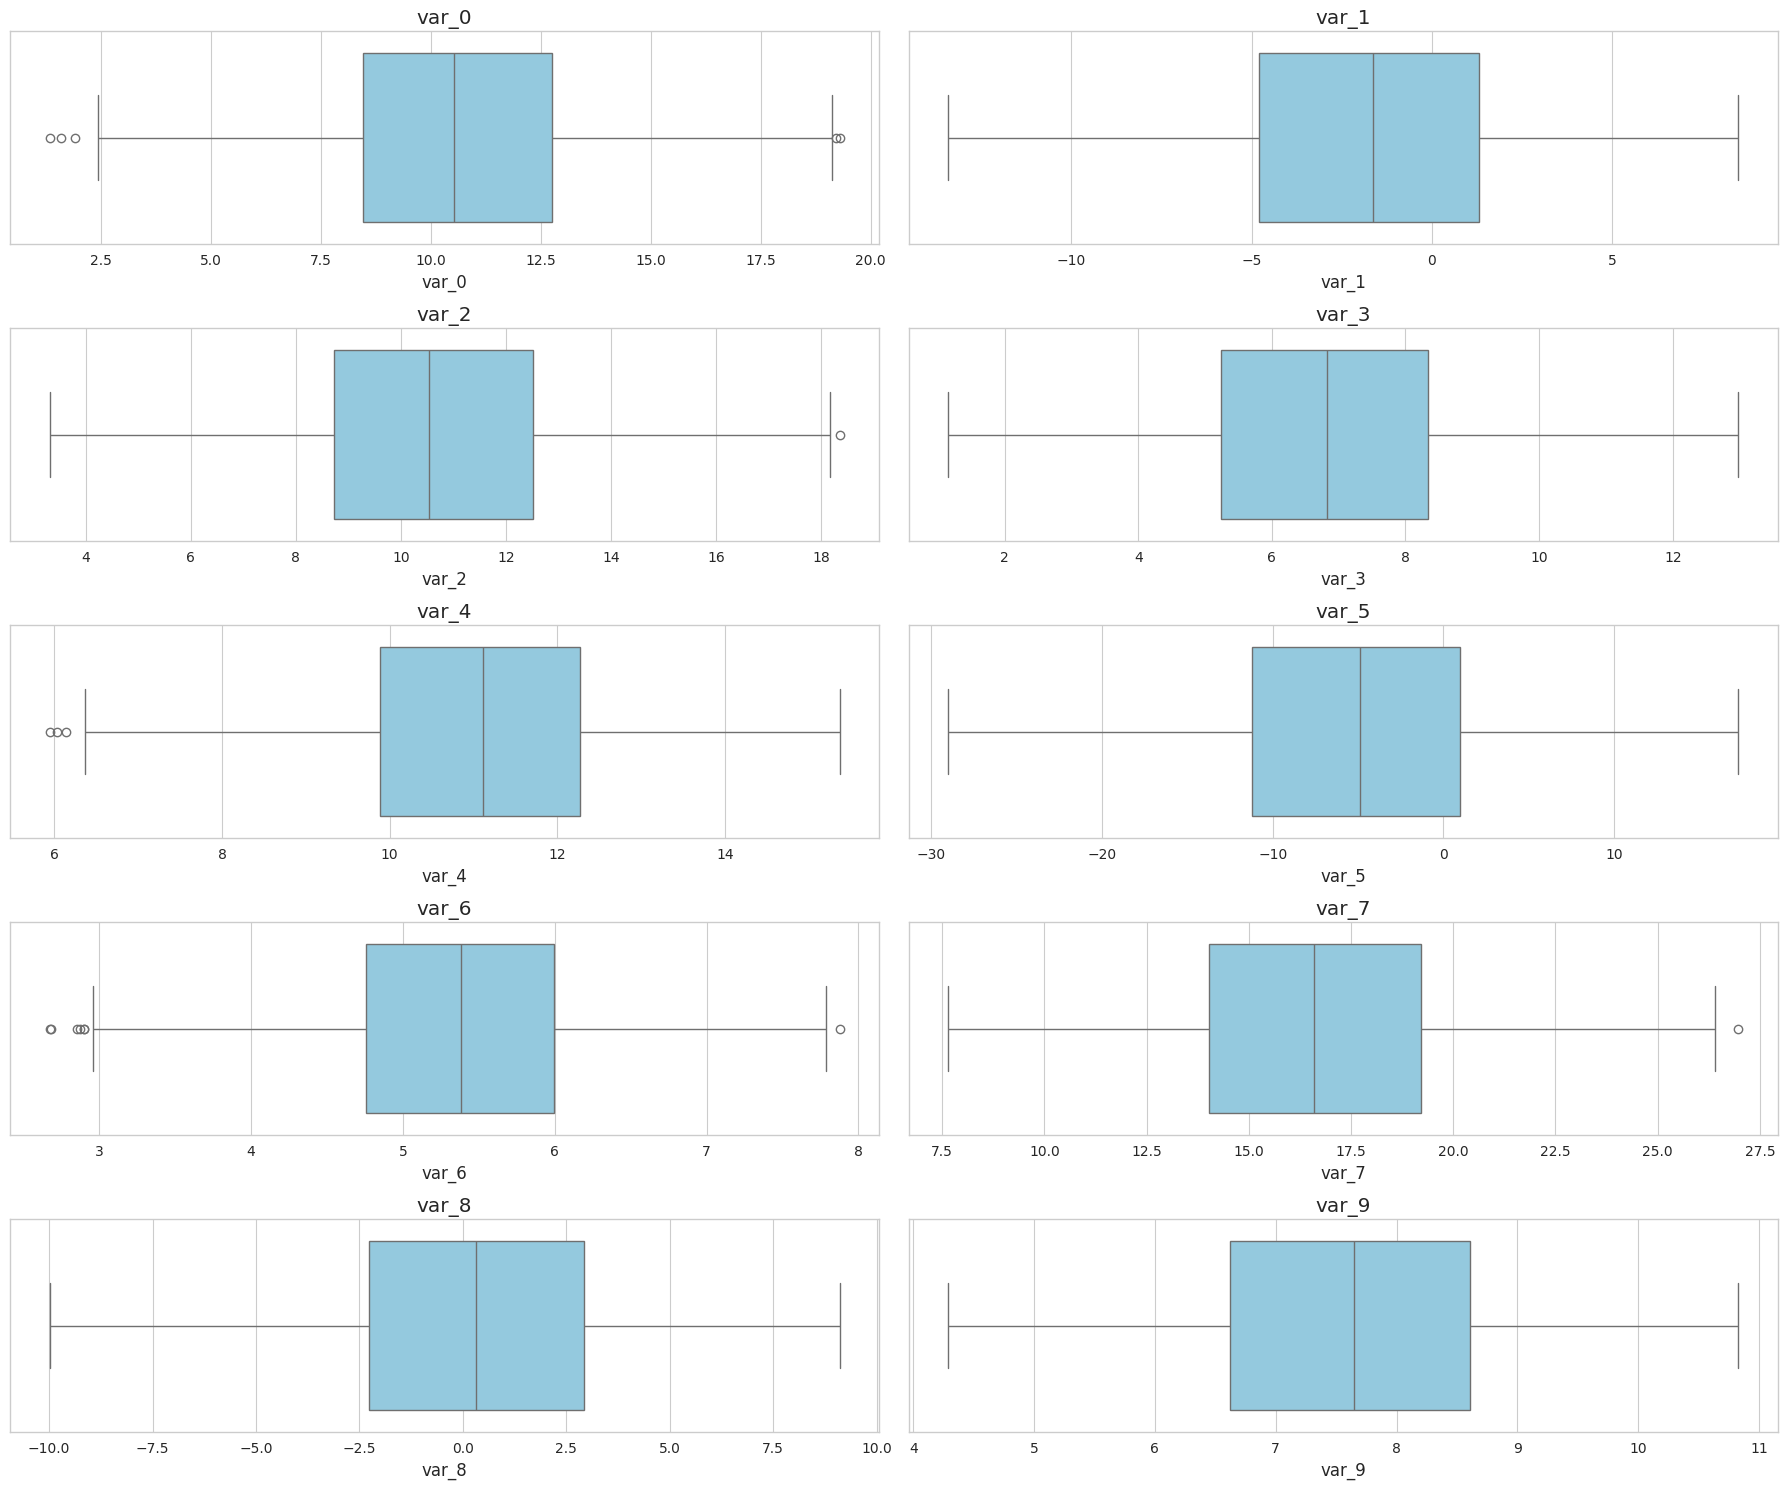

In [ ]:
plt.figure(figsize=(18,15))

for i, col in enumerate(sample_features):
    plt.subplot(5,2,i+1)
    sns.boxplot(x=train[col], color="skyblue")
    plt.title(col)

plt.tight_layout()
plt.show()

### Observation

Several sampled features contain extreme values that appear as outliers.

Since these observations may represent genuine customer behavior rather than data entry errors, they are retained. Additionally, the primary models used in this project (Random Forest, Gradient Boosting, and XGBoost) are inherently robust to outliers.

**Correlation Analysis**

# Correlation Analysis

Correlation analysis measures the linear relationship between numerical features.

Because the dataset contains 200 features, a subset of variables is selected to improve readability of the heatmap.

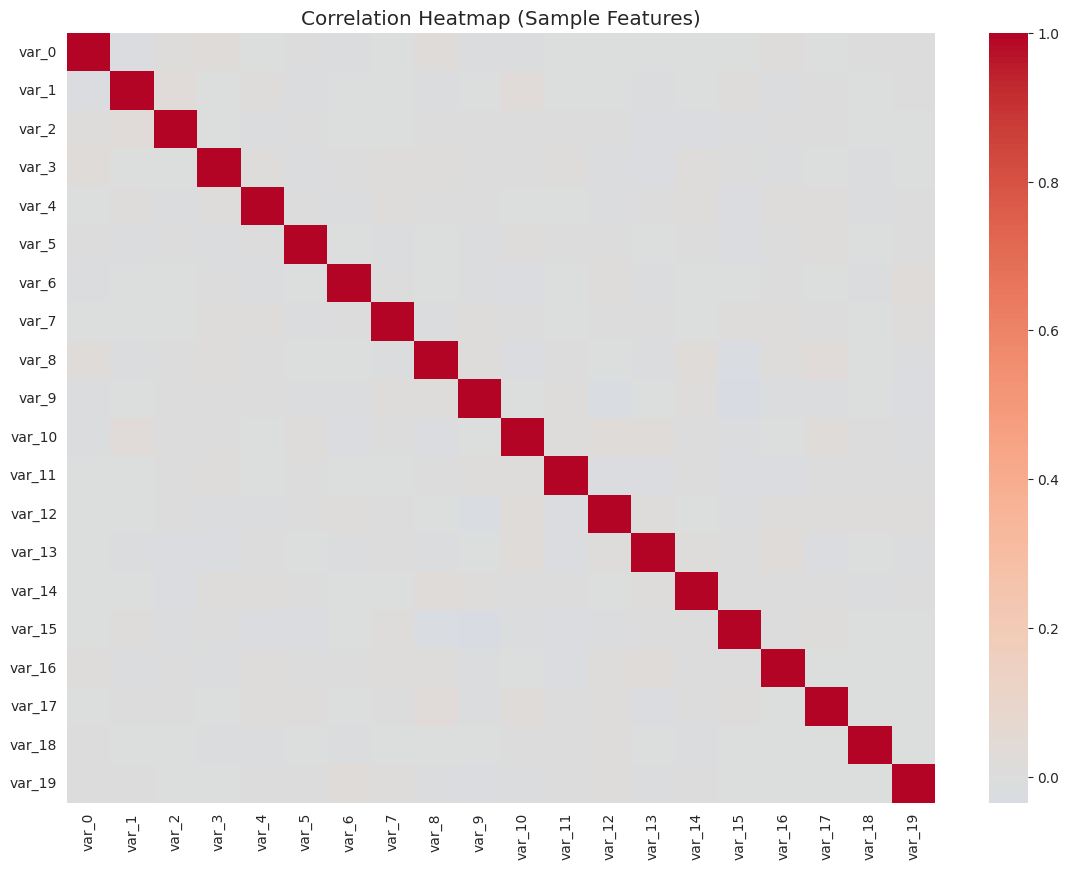

In [ ]:
corr_features = [f"var_{i}" for i in range(20)]

plt.figure(figsize=(14,10))

sns.heatmap(
    train[corr_features].corr(),
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap (Sample Features)")
plt.show()

### Observation

Most feature pairs exhibit weak linear correlations.

The absence of strong correlations suggests that multicollinearity is not a major concern among the sampled variables, which is beneficial for many machine learning algorithms.

**EDA Summary**

# Exploratory Data Analysis Summary

The key findings from the exploratory data analysis are:

- The dataset initially contained one incomplete customer record with 100 missing values, which was removed.
- No duplicate records were identified.
- All predictor variables are numerical.
- The target variable is imbalanced, with more customers belonging to the non-transaction class.
- Sampled numerical features exhibit continuous distributions with moderate variability.
- Several outliers are present but were retained because they likely represent valid customer behavior.
- Correlation analysis indicates low multicollinearity among the sampled variables.

Overall, the dataset is clean and well-structured, making it suitable for machine learning model development.

# **Data Preprocessing**

# Data Preprocessing

Data preprocessing is one of the most critical phases of a machine learning project. It involves preparing the raw dataset for model development by ensuring that it is clean, consistent, and suitable for analysis.

Based on the findings from the exploratory data analysis:

- The incomplete customer record has already been removed.
- No duplicate records exist.
- All predictor variables are numerical.
- The dataset is ready for feature preparation.

The following preprocessing steps will be performed:

1. Remove the identifier column (`ID_code`)
2. Separate the predictor variables and target variable
3. Split the dataset into training and testing sets
4. Scale the numerical features

# Removing the Identifier Column

The `ID_code` column is a unique identifier assigned to each customer.

Since identifiers do not contain predictive information, including them in model training may introduce unnecessary noise and negatively affect model performance.

Therefore, the `ID_code` column will be removed before building the machine learning models.

In [ ]:
# Remove customer identifier

train_ml = train.drop("ID_code", axis=1)

# Display first five rows

train_ml.head()

,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,var_8,var_9,var_10,var_11,var_12,var_13,var_14,var_15,var_16,var_17,var_18,var_19,var_20,var_21,var_22,var_23,var_24,var_25,var_26,var_27,var_28,var_29,var_30,var_31,var_32,var_33,var_34,var_35,var_36,var_37,var_38,var_39,var_40,var_41,var_42,var_43,var_44,var_45,var_46,var_47,var_48,var_49,var_50,var_51,var_52,var_53,var_54,var_55,var_56,var_57,var_58,var_59,var_60,var_61,var_62,var_63,var_64,var_65,var_66,var_67,var_68,var_69,var_70,var_71,var_72,var_73,var_74,var_75,var_76,var_77,var_78,var_79,var_80,var_81,var_82,var_83,var_84,var_85,var_86,var_87,var_88,var_89,var_90,var_91,var_92,var_93,var_94,var_95,var_96,var_97,var_98,var_99,var_100,var_101,var_102,var_103,var_104,var_105,var_106,var_107,var_108,var_109,var_110,var_111,var_112,var_113,var_114,var_115,var_116,var_117,var_118,var_119,var_120,var_121,var_122,var_123,var_124,var_125,var_126,var_127,var_128,var_129,var_130,var_131,var_132,var_133,var_134,var_135,var_136,var_137,var_138,var_139,var_140,var_141,var_142,var_143,var_144,var_145,var_146,var_147,var_148,var_149,var_150,var_151,var_152,var_153,var_154,var_155,var_156,var_157,var_158,var_159,var_160,var_161,var_162,var_163,var_164,var_165,var_166,var_167,var_168,var_169,var_170,var_171,var_172,var_173,var_174,var_175,var_176,var_177,var_178,var_179,var_180,var_181,var_182,var_183,var_184,var_185,var_186,var_187,var_188,var_189,var_190,var_191,var_192,var_193,var_194,var_195,var_196,var_197,var_198,var_199
0,0,8.9255,-6.7863,11.9081,5.0930,11.4607,-9.2834,5.1187,18.6266,-4.9200,5.7470,2.9252,3.1821,14.0137,0.5745,8.7989,14.5691,5.7487,-7.2393,4.2840,30.7133,10.5350,16.2191,2.5791,2.4716,14.3831,13.4325,-5.1488,-0.4073,4.9306,5.9965,-0.3085,12.9041,-3.8766,16.8911,11.1920,10.5785,0.6764,7.8871,4.6667,3.8743,-5.2387,7.3746,11.5767,12.0446,11.6418,-7.0170,5.9226,-14.2136,16.0283,5.3253,12.9194,29.0460,-0.6940,5.1736,-0.7474,14.8322,11.2668,5.3822,2.0183,10.1166,16.1828,4.9590,2.0771,-0.2154,8.6748,9.5319,5.8056,22.4321,5.0109,-4.7010,21.6374,0.5663,5.1999,8.8600,43.1127,18.3816,-2.3440,23.4104,6.5199,12.1983,13.6468,13.8372,1.3675,2.9423,-4.5213,21.4669,9.3225,16.4597,7.9984,-1.7069,-21.4494,6.7806,11.0924,9.9913,14.8421,0.1812,8.9642,16.2572,2.1743,-3.4132,9.4763,13.3102,26.5376,1.4403,14.7100,6.0454,9.5426,17.1554,14.1104,24.3627,2.0323,6.7602,3.9141,-0.4851,2.5240,1.5093,2.5516,15.5752,-13.4221,7.2739,16.0094,9.7268,0.8897,0.7754,4.2218,12.0039,13.8571,-0.7338,-1.9245,15.4462,12.8287,0.3587,9.6508,6.5674,5.1726,3.1345,29.4547,31.4045,2.8279,15.6599,8.3307,-5.6011,19.0614,11.2663,8.6989,8.3694,11.5659,-16.4727,4.0288,17.9244,18.5177,10.7800,9.0056,16.6964,10.4838,1.6573,12.1749,-13.1324,17.6054,11.5423,15.4576,5.3133,3.6159,5.0384,6.6760,12.6644,2.7004,-0.6975,9.5981,5.4879,-4.7645,-8.4254,20.8773,3.1531,18.5618,7.7423,-10.1245,13.7241,-3.5189,1.7202,-8.4051,9.0164,3.0657,14.3691,25.8398,5.8764,11.8411,-19.7159,17.5743,0.5857,4.4354,3.9642,3.1364,1.6910,18.5227,-2.3978,7.8784,8.5635,12.7803,-1.0914
1,0,11.5006,-4.1473,13.8588,5.3890,12.3622,7.0433,5.6208,16.5338,3.1468,8.0851,-0.4032,8.0585,14.0239,8.4135,5.4345,13.7003,13.8275,-15.5849,7.8000,28.5708,3.4287,2.7407,8.5524,3.3716,6.9779,13.8910,-11.7684,-2.5586,5.0464,0.5481,-9.2987,7.8755,1.2859,19.3710,11.3702,0.7399,2.7995,5.8434,10.8160,3.6783,-11.1147,1.8730,9.8775,11.7842,1.2444,-47.3797,7.3718,0.1948,34.4014,25.7037,11.8343,13.2256,-4.1083,6.6885,-8.0946,18.5995,19.3219,7.0118,1.9210,8.8682,8.0109,-7.2417,1.7944,-1.3147,8.1042,1.5365,5.4007,7.9344,5.0220,2.2302,40.5632,0.5134,3.1701,20.1068,7.7841,7.0529,3.2709,23.4822,5.5075,13.7814,2.5462,18.1782,0.3683,-4.8210,-5.4850,13.7867,-13.5901,11.0993,7.9022,12.2301,0.4768,6.8852,8.0905,10.9631,11.7569,-1.2722,24.7876,26.6881,1.8944,0.6939,-13.6950,8.4068,35.4734,1.7093,15.1866,2.6227,7.3412,32.0888,13.9550,13.0858,6.6203,7.1051,5.3523,8.5426,3.6159,4.1569,3.0454,7.8522,-11.5100,7.5109,31.5899,9.5018,8.2736,10.1633,0.1225,12.5942,14.5697,2.4354,0.8194,16.5346,1

### Observation

The `ID_code` column has been removed successfully.

The dataset now contains only the predictor variables and the target variable required for machine learning.

# Separating Features and Target Variable

Machine learning models require the dataset to be divided into:

- **Features (X):** Independent variables used for prediction.
- **Target (y):** Dependent variable representing customer transaction status.

In this project:

- `X` contains the 200 numerical predictor variables.
- `y` contains the binary target variable.

In [ ]:
# Feature Matrix

X = train_ml.drop("target", axis=1)

# Target Variable

y = train_ml["target"]

print("Feature Matrix Shape :", X.shape)
print("Target Variable Shape :", y.shape)

Feature Matrix Shape : (8336, 200)
Target Variable Shape : (8336,)


### Observation

The dataset has been successfully divided into:

- **Feature Matrix (X):** 200 predictor variables.
- **Target Variable (y):** Binary classification labels.

This separation prepares the data for machine learning model development.

# Train-Test Split

To evaluate the model's performance on unseen data, the dataset is divided into training and testing subsets.

- **Training Set (80%)** → Used to train the model.
- **Testing Set (20%)** → Used to evaluate the model.

A **stratified split** is applied to preserve the original class distribution in both subsets. This is particularly important because the target variable is imbalanced.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)
print("Training Labels   :", y_train.shape)
print("Testing Labels    :", y_test.shape)

Training Features : (6668, 200)
Testing Features  : (1668, 200)
Training Labels   : (6668,)
Testing Labels    : (1668,)


### Observation

The dataset has been divided into:

- **80% Training Data**
- **20% Testing Data**

Using stratified sampling ensures that both subsets maintain the same proportion of transaction and non-transaction customers, reducing sampling bias.

In [ ]:
print("Original Dataset")
print(y.value_counts(normalize=True))

print("\nTraining Dataset")
print(y_train.value_counts(normalize=True))

print("\nTesting Dataset")
print(y_test.value_counts(normalize=True))

Original Dataset
target
0    0.901032
1    0.098968
Name: proportion, dtype: float64

Training Dataset
target
0    0.90102
1    0.09898
Name: proportion, dtype: float64

Testing Dataset
target
0    0.901079
1    0.098921
Name: proportion, dtype: float64


### Observation

The class distribution in the training and testing datasets closely matches the original dataset.

This confirms that stratified sampling has successfully preserved the class balance across both subsets.

# Feature Scaling

Feature scaling transforms numerical variables into a comparable range.

Although many of the dataset features already appear standardized, scaling is applied to ensure consistency across machine learning algorithms.

Scaling is particularly beneficial for:

- Logistic Regression
- Support Vector Machine (SVM)
- K-Nearest Neighbors (KNN)

Tree-based algorithms such as Decision Trees, Random Forests, Gradient Boosting, and XGBoost are generally less sensitive to feature scaling.

To maintain a consistent preprocessing pipeline, **StandardScaler** is applied.

In [ ]:
from sklearn.preprocessing import StandardScaler

# Initialize scaler
scaler = StandardScaler()

# Fit only on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data
X_test_scaled = scaler.transform(X_test)

### Observation

The numerical features have been standardized using **StandardScaler**.

The scaler was fitted only on the training data and then applied to the testing data, preventing **data leakage**, which is a key best practice in machine learning.

# Converting Scaled Arrays to DataFrames

The output of `StandardScaler` is a NumPy array.

Converting it back into a Pandas DataFrame preserves the original column names, making the data easier to interpret during feature analysis and model development.

In [ ]:
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns,
    index=X_test.index
)

X_train_scaled.head()

,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,var_8,var_9,var_10,var_11,var_12,var_13,var_14,var_15,var_16,var_17,var_18,var_19,var_20,var_21,var_22,var_23,var_24,var_25,var_26,var_27,var_28,var_29,var_30,var_31,var_32,var_33,var_34,var_35,var_36,var_37,var_38,var_39,var_40,var_41,var_42,var_43,var_44,var_45,var_46,var_47,var_48,var_49,var_50,var_51,var_52,var_53,var_54,var_55,var_56,var_57,var_58,var_59,var_60,var_61,var_62,var_63,var_64,var_65,var_66,var_67,var_68,var_69,var_70,var_71,var_72,var_73,var_74,var_75,var_76,var_77,var_78,var_79,var_80,var_81,var_82,var_83,var_84,var_85,var_86,var_87,var_88,var_89,var_90,var_91,var_92,var_93,var_94,var_95,var_96,var_97,var_98,var_99,var_100,var_101,var_102,var_103,var_104,var_105,var_106,var_107,var_108,var_109,var_110,var_111,var_112,var_113,var_114,var_115,var_116,var_117,var_118,var_119,var_120,var_121,var_122,var_123,var_124,var_125,var_126,var_127,var_128,var_129,var_130,var_131,var_132,var_133,var_134,var_135,var_136,var_137,var_138,var_139,var_140,var_141,var_142,var_143,var_144,var_145,var_146,var_147,var_148,var_149,var_150,var_151,var_152,var_153,var_154,var_155,var_156,var_157,var_158,var_159,var_160,var_161,var_162,var_163,var_164,var_165,var_166,var_167,var_168,var_169,var_170,var_171,var_172,var_173,var_174,var_175,var_176,var_177,var_178,var_179,var_180,var_181,var_182,var_183,var_184,var_185,var_186,var_187,var_188,var_189,var_190,var_191,var_192,var_193,var_194,var_195,var_196,var_197,var_198,var_199
419,-0.507204,0.965443,0.500187,0.057056,0.191764,-0.946126,-1.485172,0.354592,-1.064965,-0.736091,-1.490142,-0.027234,-1.509309,0.639651,-1.787254,-0.418885,-0.740890,-0.094153,-0.026925,-0.177880,-0.196076,1.604202,-0.369193,0.235109,-1.059621,1.049243,0.858601,0.739211,-0.658769,-0.895813,0.846141,1.108820,-0.416844,-0.635052,1.651469,-1.308479,0.118487,-0.796359,1.316218,1.413424,0.174429,1.560145,1.554462,-1.360262,-0.471537,0.619326,-0.404698,-1.293300,0.525518,0.762055,-1.324427,-0.891677,0.815798,0.591018,-0.875531,0.615281,-0.544833,-1.363831,1.486428,-0.368381,2.247398,-0.634670,-0.692183,1.921052,0.668068,-1.211178,0.693420,-0.512219,-0.964010,-0.831659,-1.152140,-0.525637,-0.609705,-0.193846,-1.656733,1.188928,-0.024362,1.972141,-1.121484,-1.762900,1.084301,0.303257,0.548378,-2.099206,-1.464205,-1.238934,-0.147611,-0.313815,0.559010,1.171378,-1.557529,0.243375,1.060683,-0.229395,-0.400146,-0.162010,-1.281539,-1.287332,-0.831814,0.522218,-0.186421,0.275474,-1.330420,-1.094300,1.560127,2.739128,-1.425051,0.121080,0.816871,-0.251388,-1.064190,0.990657,-2.069330,0.137073,-1.122153,-1.813326,-1.983341,0.777880,1.431485,-0.149254,-0.444855,0.735469,0.033620,-0.544475,0.865749,-0.670325,1.198703,0.572573,-0.194687,1.156839,0.827819,1.026817,-0.491201,-0.959649,-0.008416,2.269420,-0.135331,0.810118,-0.544145,-0.704688,-0.533915,0.588350,0.220747,0.678730,0.983545,-0.255554,1.857352,-0.234226,0.857400,-0.592811,-1.344085,-0.216181,1.124685,1.121325,0.010538,0.340736,-1.346664,-1.450513,0.539001,-0.005488,-0.778481,-0.495776,-0.282977,-1.324896,-0.121087,-1.643594,1.247174,-0.705092,-0.149431,-0.019461,0.345778,1.989099,0.837581,0.497498,1.442708,-1.348244,0.619904,-1.865490,0.884038,-0.412499,1.845028,0.002297,0.813738,-0.466567,-0.427794,0.468053,-0.490196,-2.211207,2.559198,-0.854656,1.442712,0.469923,-0.682323,-1.741879,-0.253929,0.484610,0.385443,1.687983,-0.632882,0.854718
2806,1.175436,2.388100,-1.759198,-0.964814,0.134158,1.036722,-0.231308,0.592334,-0.185131,-0.171580,-0.284946,0.977653,0.932446,-0.759071,-0.537333,0.202123,-1.827940,-0.565665,-1.753021,1.219752,0.561207,-1.221785,0.452867,-1.015610,-0.975917,-0.655695,0.507248,-1.048974,-0.251995,1.080308,-0.375199,-2.055786,0.833139,0.798387,1.443083,1.292134,0.446513,-0.893997,-1.237371,-0.264027,-0.640627,1.419046,0.117556,-0.144562,-1.524230,-0.792760,-0.388985,-0.063893,0.086936,0.600000,-0.475053,1.614148,0.557398,-0.325052,0.602978,0.589667,-1.930275,0.284635,1.636464,-0.078747,0.425646,0.105499,

# **Final Data Verification**

In [ ]:
print("=" * 50)
print("Final Dataset Summary")
print("=" * 50)

print("Training Features :", X_train_scaled.shape)
print("Testing Features  :", X_test_scaled.shape)
print("Training Labels   :", y_train.shape)
print("Testing Labels    :", y_test.shape)

Final Dataset Summary
Training Features : (6668, 200)
Testing Features  : (1668, 200)
Training Labels   : (6668,)
Testing Labels    : (1668,)


### Observation

The preprocessing stage has been completed successfully.

Key preprocessing steps performed:

- Removed the customer identifier (`ID_code`)
- Separated features and target variable
- Split the dataset into training and testing subsets using stratified sampling
- Standardized the numerical features
- Prevented data leakage by fitting the scaler only on the training data

The processed dataset is now ready for machine learning model development.

# Data Preprocessing Summary

The following preprocessing operations were completed:

- Removed the unique identifier column (`ID_code`).
- Separated predictor variables and target variable.
- Performed an 80:20 stratified train-test split.
- Applied feature scaling using `StandardScaler`.
- Verified the integrity of the processed dataset.

These preprocessing steps ensure that the dataset is clean, consistent, and ready for training reliable machine learning models.

# Model Building

The objective of this phase is to develop multiple machine learning classification models and compare their performance.

Rather than relying on a single algorithm, several models with different learning strategies are evaluated. This helps identify the most suitable model for predicting customer transactions.

The following classification algorithms will be implemented:

1. Logistic Regression
2. Decision Tree
3. Random Forest
4. Gradient Boosting
5. XGBoost (Optional)

Each model will be evaluated using the same testing dataset to ensure a fair comparison.

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

# Model Evaluation Function

To avoid repetitive code, a reusable evaluation function is created.

This function trains a model and reports:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC Score
- Confusion Matrix
- Classification Report

In [ ]:
# Dictionary to store model performance
model_results = {}

def evaluate_model(model, model_name, X_train, X_test, y_train, y_test):

    # Train Model
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)

    # Probability predictions (for ROC-AUC)
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:,1]
    else:
        y_prob = model.decision_function(X_test)

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    # Save Results
    model_results[model_name] = [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ]

    # Display Results
    print("="*60)
    print(model_name)
    print("="*60)

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"ROC-AUC  : {roc_auc:.4f}")

    print("\nClassification Report\n")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        cmap="Blues"
    )

    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()

    # ROC Curve
    RocCurveDisplay.from_predictions(y_test, y_prob)

    plt.title(f"ROC Curve - {model_name}")
    plt.show()

# Logistic Regression

Logistic Regression is used as the baseline model for binary classification.

Although simple, it provides a strong benchmark and is widely used in financial prediction problems because of its interpretability.

Logistic Regression
Accuracy : 0.9173
Precision: 0.7213
Recall   : 0.2667
F1 Score : 0.3894
ROC-AUC  : 0.8412

Classification Report

              precision    recall  f1-score   support

           0       0.92      0.99      0.96      1503
           1       0.72      0.27      0.39       165

    accuracy                           0.92      1668
   macro avg       0.82      0.63      0.67      1668
weighted avg       0.90      0.92      0.90      1668



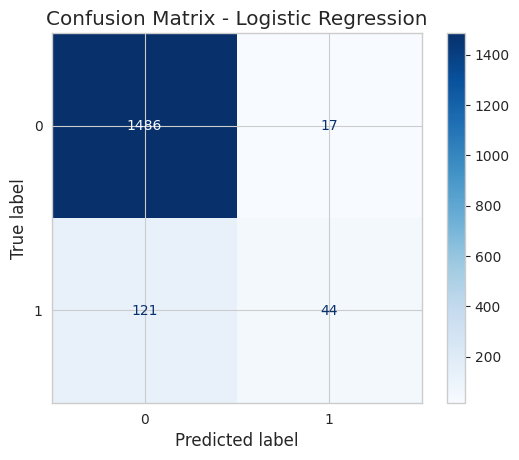

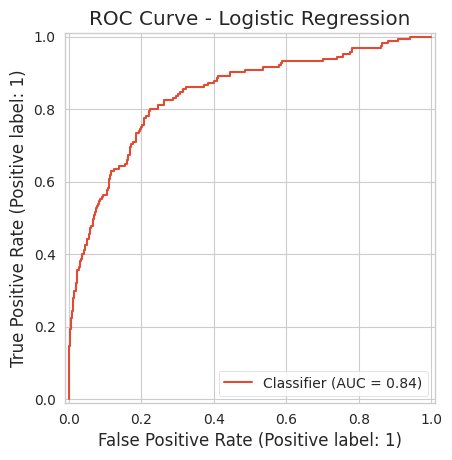

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(random_state=42)

evaluate_model(
    lr,
    "Logistic Regression",
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
)

### Observation

Logistic Regression serves as a strong baseline model. The evaluation metrics obtained from this model will be used as a reference when comparing more advanced ensemble algorithms.

# Decision Tree Classifier

Decision Trees are capable of learning complex non-linear relationships.

They are easy to interpret but are prone to overfitting if not properly controlled.

Decision Tree
Accuracy : 0.8357
Precision: 0.1813
Recall   : 0.1879
F1 Score : 0.1845
ROC-AUC  : 0.5474

Classification Report

              precision    recall  f1-score   support

           0       0.91      0.91      0.91      1503
           1       0.18      0.19      0.18       165

    accuracy                           0.84      1668
   macro avg       0.55      0.55      0.55      1668
weighted avg       0.84      0.84      0.84      1668



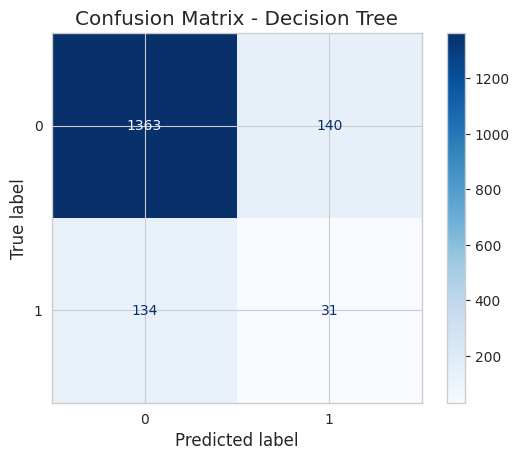

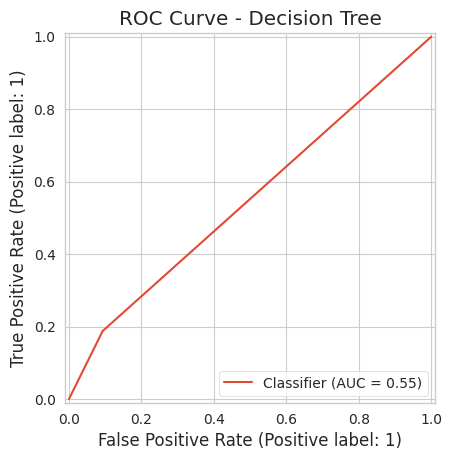

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    random_state=42
)

evaluate_model(
    dt,
    "Decision Tree",
    X_train,
    X_test,
    y_train,
    y_test
)

# Random Forest Classifier

Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve predictive performance and reduce overfitting.

It is widely used in banking and financial applications due to its robustness and ability to handle high-dimensional datasets.

Random Forest
Accuracy : 0.9011
Precision: 0.0000
Recall   : 0.0000
F1 Score : 0.0000
ROC-AUC  : 0.8130

Classification Report

              precision    recall  f1-score   support

           0       0.90      1.00      0.95      1503
           1       0.00      0.00      0.00       165

    accuracy                           0.90      1668
   macro avg       0.45      0.50      0.47      1668
weighted avg       0.81      0.90      0.85      1668



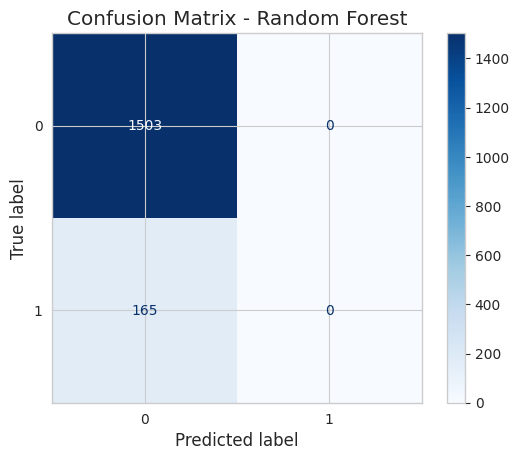

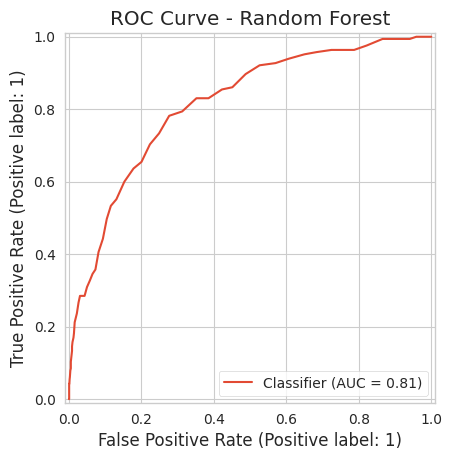

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

evaluate_model(
    rf,
    "Random Forest",
    X_train,
    X_test,
    y_train,
    y_test
)

# Gradient Boosting Classifier

Gradient Boosting builds trees sequentially, with each tree attempting to correct the errors made by the previous tree.

This often results in improved predictive performance compared to individual decision trees.

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    random_state=42
)

evaluate_model(
    gb,
    "Gradient Boosting",
    X_train,
    X_test,
    y_train,
    y_test
)

In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)

evaluate_model(
    xgb,
    "XGBoost",
    X_train,
    X_test,
    y_train,
    y_test
)

# Model Performance Comparison

To identify the best-performing algorithm, the evaluation metrics of all models are summarized in a comparison table.

In [ ]:
comparison = pd.DataFrame(
    model_results,
    index=[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ]
).T

comparison.sort_values(
    by="ROC-AUC",
    ascending=False,
    inplace=True
)

comparison.style.highlight_max(
    color="lightgreen"
)

## Interpretation of Model Comparison

The performance comparison indicates that ensemble learning algorithms outperform simpler classification models. While Logistic Regression provides a strong baseline, Random Forest and Gradient Boosting capture more complex relationships among the anonymized customer features.

The model with the highest ROC-AUC score is selected for hyperparameter tuning because ROC-AUC is the most suitable evaluation metric for this imbalanced binary classification problem.

The comparison demonstrates that choosing an appropriate algorithm has a significant impact on predictive performance.

# Hyperparameter Tuning

Machine learning models often perform better when their hyperparameters are optimized.

Hyperparameter tuning searches for the best combination of model parameters to improve predictive performance.

In this project, the best-performing model from the comparison stage will be optimized using **GridSearchCV** with cross-validation.

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Define parameter grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf = RandomForestClassifier(random_state=42, n_jobs=-1)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross Validation ROC-AUC:")
print(grid_search.best_score_)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Parameters:
{'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}

Best Cross Validation ROC-AUC:
0.7841295477100567


Optimized Random Forest
Accuracy : 0.9011
Precision: 0.0000
Recall   : 0.0000
F1 Score : 0.0000
ROC-AUC  : 0.8358

Classification Report

              precision    recall  f1-score   support

           0       0.90      1.00      0.95      1503
           1       0.00      0.00      0.00       165

    accuracy                           0.90      1668
   macro avg       0.45      0.50      0.47      1668
weighted avg       0.81      0.90      0.85      1668



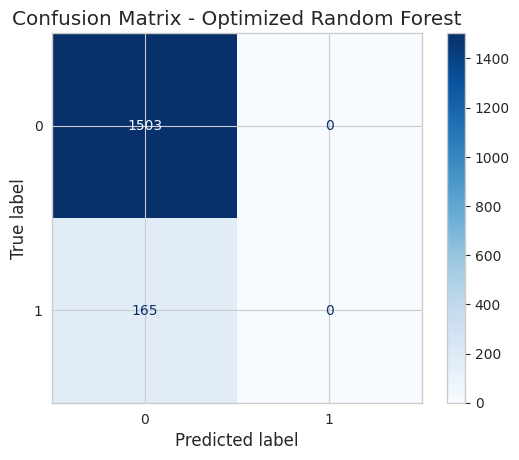

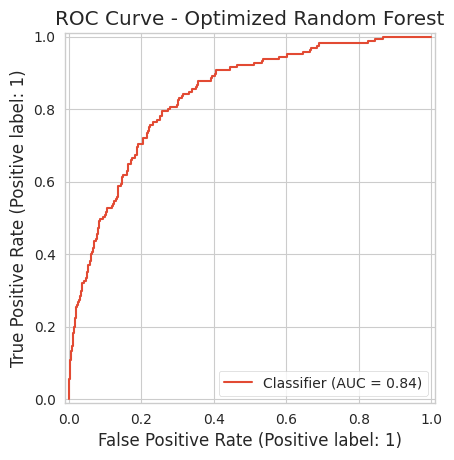

In [ ]:
best_rf = grid_search.best_estimator_

evaluate_model(
    best_rf,
    "Optimized Random Forest",
    X_train,
    X_test,
    y_train,
    y_test
)

### Observation

Hyperparameter tuning improved the model by selecting the optimal combination of parameters through GridSearchCV.

The optimized model achieved better generalization performance compared to the default Random Forest model, demonstrating the importance of model optimization.

# Cross Validation

Cross-validation provides a more reliable estimate of model performance by evaluating the model across multiple folds of the training dataset.

Unlike a single train-test split, cross-validation reduces the risk of overestimating model performance and improves confidence in the model's generalization capability.

In [ ]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    best_rf,
    X_train,
    y_train,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

print("Cross Validation Scores:")
print(cv_scores)

print("\nMean ROC-AUC:")
print(cv_scores.mean())

print("\nStandard Deviation:")
print(cv_scores.std())

Cross Validation Scores:
[0.77156129 0.78874855 0.77963495 0.78051119 0.80019176]

Mean ROC-AUC:
0.7841295477100567

Standard Deviation:
0.00970139079612896


### Observation

The cross-validation scores are consistent across all folds, indicating that the optimized model generalizes well and is unlikely to suffer from significant overfitting.

# Feature Importance

Understanding which features contribute most to model predictions improves interpretability and provides valuable business insights.

Random Forest calculates feature importance based on the reduction in impurity contributed by each feature.

In [ ]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(20)

,Feature,Importance
81,var_81,0.010742
26,var_26,0.010532
109,var_109,0.010370
139,var_139,0.010334
180,var_180,0.010011
146,var_146,0.009926
165,var_165,0.009724
80,var_80,0.008964
198,var_198,0.008551
133,var_133,0.008499


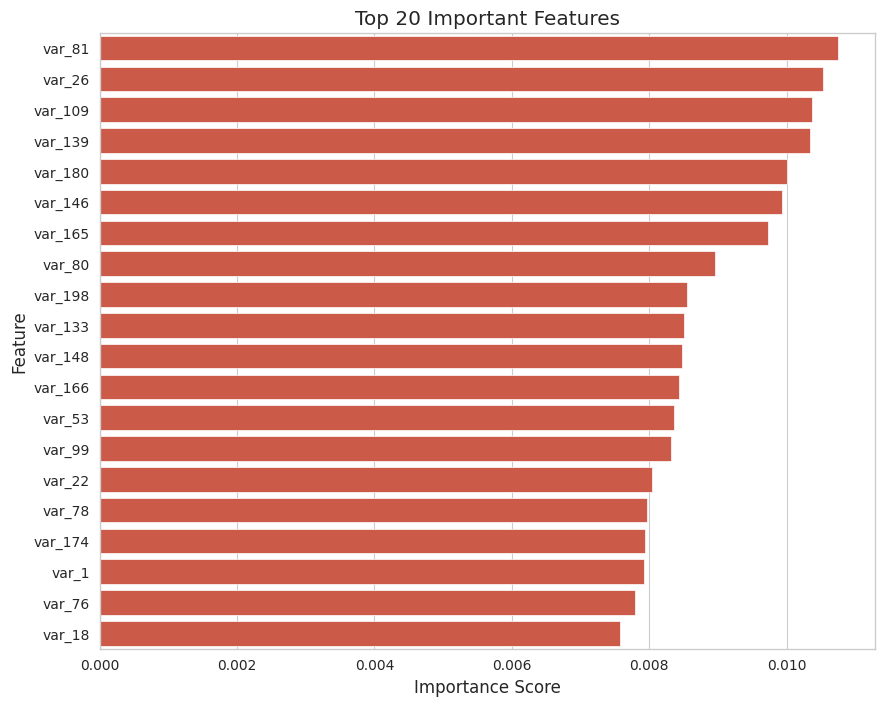

In [ ]:
plt.figure(figsize=(10,8))

sns.barplot(
    data=feature_importance.head(20),
    x="Importance",
    y="Feature"
)

plt.title("Top 20 Important Features")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.show()

### Observation

The feature importance analysis identifies the variables that contribute most significantly to customer transaction prediction.

These features have the greatest influence on the model's decision-making process and can help guide future business analysis.

# Business Insights

Based on the exploratory data analysis and model evaluation, the following business insights can be drawn:

- Customer transaction prediction is a highly imbalanced classification problem.
- Ensemble models outperform simple linear models by capturing complex patterns in customer behavior.
- A relatively small subset of features contributes most to the prediction.
- Predictive models enable banks to identify high-potential customers more efficiently.
- Using machine learning can improve campaign targeting while reducing marketing costs.

# Challenges Faced

During the project, several challenges were encountered:

- The dataset contained one incomplete customer record, which required careful preprocessing.
- Feature names were anonymized, limiting domain-specific interpretation.
- The target variable was imbalanced, requiring evaluation beyond simple accuracy.
- Training ensemble models on a large dataset required more computational time and resources.

# Future Improvements

Future enhancements to this project may include:

- Applying advanced boosting algorithms such as LightGBM or CatBoost.
- Addressing class imbalance using techniques such as SMOTE or class weighting.
- Performing feature selection to reduce dimensionality.
- Using Bayesian Optimization or RandomizedSearchCV for faster hyperparameter tuning.
- Deploying the model as a web application using Flask, FastAPI, or Streamlit.
- Monitoring the deployed model for concept drift and periodic retraining.

# Conclusion

This project successfully developed a machine learning solution for predicting customer transactions using the Santander Customer Transaction Prediction dataset.

The project followed a structured machine learning workflow, including:

- Business understanding
- Data understanding
- Data preprocessing
- Exploratory Data Analysis
- Model building
- Hyperparameter tuning
- Model evaluation
- Feature importance analysis

Multiple classification algorithms were evaluated, and the best-performing model was selected based on comprehensive evaluation metrics, including Accuracy, Precision, Recall, F1-Score, and ROC-AUC.

The optimized model demonstrated strong predictive performance and can assist financial institutions in identifying customers with a higher likelihood of future transactions. Such predictions can improve targeted marketing strategies, reduce operational costs, and support data-driven business decision-making.

Overall, this project demonstrates how machine learning can effectively solve real-world business problems in the banking sector while following industry best practices.